## MODELO BASE (BASELINE)

### By:
Cristian David Ceballos Velez

### Date:
2026-08-25

### Description:
Creación de un modelo base (baseline) para el dataset `corazon.csv`, como referencia para
comparar contra modelos de machine learning más complejos en etapas posteriores. Se evalúan
dos enfoques: un **modelo Dummy** (referencia mínima exigida por scikit-learn) y un
**modelo heurístico** basado en reglas clínicas conocidas para enfermedad cardíaca.

Estructura basada en: [Modelo Base - Jose R. Zapata](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/5-baseline_model/)

> **Nota:** las reglas del modelo heurístico (sección 6.2) están basadas en conocimiento clínico
> general del dataset de Cleveland (origen común de este tipo de datasets). **Ajusta los umbrales
> y variables según los resultados reales de tu análisis bivariable/multivariable (`3-analysis`).**

## 📚 1. Importar librerías

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    classification_report,
)
from sklearn.model_selection import (
    KFold,
    ShuffleSplit,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline

print("Pandas version:", pd.__version__)

Pandas version: 3.0.5


## 💾 2. Cargar datos

In [ ]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

df = pd.read_parquet(DATA_DIR / "02_intermediate" / "corazon_type_fixed.parquet", engine="pyarrow")

TARGET = "disease"
df[TARGET] = df[TARGET].astype(int)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1466 entries, 0 to 1465
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   age         1462 non-null   Int8    
 1   sex         1423 non-null   category
 2   chest_pain  1424 non-null   category
 3   rest_bp     1422 non-null   Int16   
 4   chol        1420 non-null   Int16   
 5   fbs         1420 non-null   boolean 
 6   rest_ecg    1420 non-null   category
 7   max_hr      1443 non-null   Int16   
 8   exang       1466 non-null   boolean 
 9   old_peak    1464 non-null   float32 
 10  slope       1466 non-null   float64 
 11  ca          1437 non-null   Int8    
 12  thal        1458 non-null   category
 13  disease     1466 non-null   int64   
dtypes: Int16(3), Int8(2), boolean(2), category(4), float32(1), float64(1), int64(1)
memory usage: 59.2 KB


## 🔎 3. Selección de la variable más importante

Antes de definir las reglas del modelo heurístico, se cuantifica la asociación de cada
variable con el target: correlación biserial-puntual para numéricas, y Chi² (V de Cramér)
para categóricas. Esto complementa (o reemplaza) los resultados del análisis bivariable
del notebook de EDA.

In [ ]:
cols_numeric_all = list(df.select_dtypes(include=["number"]).columns)
if TARGET in cols_numeric_all:
    cols_numeric_all.remove(TARGET)

cols_categoric_all = list(df.select_dtypes(include=["category", "object", "boolean"]).columns)
if TARGET in cols_categoric_all:
    cols_categoric_all.remove(TARGET)

# Asociación de variables numéricas con el target (correlación punto-biserial)
resultados_numericas = []
for col in cols_numeric_all:
    datos = df[[col, TARGET]].dropna()
    corr, p_valor = stats.pointbiserialr(datos[TARGET], datos[col])
    resultados_numericas.append({"variable": col, "correlacion": corr, "p_valor": p_valor})

df_num = pd.DataFrame(resultados_numericas).sort_values("correlacion", key=abs, ascending=False)
df_num

,variable,correlacion,p_valor
4,old_peak,0.475945,1.246327e-83
3,max_hr,-0.454776,1.447246e-74
5,slope,0.415157,3.640606e-62
6,ca,0.364802,1.816334e-46
0,age,0.214139,1.262885e-16
1,rest_bp,0.128342,1.200714e-06
2,chol,0.127999,1.304704e-06


In [ ]:
# Asociación de variables categóricas con el target (Chi² y V de Cramér)
resultados_categoricas = []
for col in cols_categoric_all:
    tabla = pd.crosstab(df[col], df[TARGET])
    chi2, p_valor, dof, _ = stats.chi2_contingency(tabla)
    n = tabla.sum().sum()
    v_cramer = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    resultados_categoricas.append({"variable": col, "v_cramer": v_cramer, "p_valor": p_valor})

df_cat = pd.DataFrame(resultados_categoricas).sort_values("v_cramer", ascending=False)
df_cat

,variable,v_cramer,p_valor
5,thal,0.531858,2.768991e-90
1,chest_pain,0.522758,4.971399e-84
4,exang,0.499235,1.897807e-81
0,sex,0.245184,2.266513e-20
3,rest_ecg,0.124234,2.848079e-06
2,fbs,0.010731,6.859290e-01


**Justificación de la variable más importante:** revisa la tabla anterior — la variable con
mayor correlación (numéricas) o V de Cramér (categóricas) y p-valor significativo (< 0.05) es la
que más información aporta sobre `disease`. En datasets clínicos de este tipo, `thal`, `ca` y
`chest_pain` suelen ser las más fuertes. **Reemplaza el texto con tu hallazgo real** una vez
ejecutes las celdas anteriores con tus datos.

## 👷 4. Preparación de datos para el modelo heurístico

Para el modelo heurístico solo se necesitan las variables identificadas como más relevantes en la sección 3. Ajusta `selected_features` según tus resultados.

In [5]:
selected_features = ["chest_pain", "thal", "ca", TARGET]  # <-- AJUSTAR según sección 3

heart_baseline = df[selected_features].copy()
heart_baseline.isna().sum()

chest_pain    42
thal           8
ca            29
disease        0
dtype: int64

## ✂️ 5. Train / Test split

In [6]:
X_features = heart_baseline.drop(columns=[TARGET])
y_target = heart_baseline[TARGET]

x_train, x_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.2, stratify=y_target, random_state=42
)

print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (1172, 3) (1172,)
Test: (294, 3) (294,)


## 🔧 6. Modelos base

### 6.1 Preprocesador

Para el modelo heurístico las columnas categóricas pasan sin transformar (`passthrough`), solo
se imputan valores faltantes en `ca` (numérica).

In [7]:
cols_categoric = ["chest_pain", "thal"]  # <-- AJUSTAR
cols_numeric = ["ca"]  # <-- AJUSTAR

numeric_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
categoric_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent"))])

preprocessor = ColumnTransformer(
    transformers=[
        ("categoric", categoric_pipe, cols_categoric),
        ("numeric", numeric_pipe, cols_numeric),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categoric', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feat

### 6.2 Modelo heurístico

Regla clínica de referencia (**ajustar según hallazgos reales de tu EDA**):
- Si `chest_pain` = "asymptomatic", o
- `thal` en {"fixed", "reversable"} (defecto de perfusión), o
- `ca` > 0 (vasos principales coloreados por fluoroscopia)

→ se predice `disease` = 1, de lo contrario 0.

In [ ]:
class HeuristicModel(BaseEstimator, ClassifierMixin):
    """Modelo heurístico basado en reglas clínicas para el dataset de corazón."""

    def fit(self, X, y=None):
        if y is not None:
            self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        chest_pain_riesgo = "asymptomatic"
        thal_riesgo = {"fixed", "reversable"}
        ca_umbral = 0

        predictions = []
        for row in X:
            chest_pain, thal, ca = row[0], row[1], row[2]
            if (chest_pain == chest_pain_riesgo) or (thal in thal_riesgo) or (ca > ca_umbral):
                predictions.append(1)
            else:
                predictions.append(0)
        return np.array(predictions)

### 6.3 Modelo Dummy (referencia mínima)

In [9]:
dummy_model = DummyClassifier(strategy="most_frequent", random_state=42)

## 📊 7. Validación cruzada — comparación Dummy vs. Heurístico

In [10]:
scoring_metrics = ["accuracy", "f1", "precision", "recall"]
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

modelos = {
    "Dummy": dummy_model,
    "Heuristico": HeuristicModel(),
}

resultados_cv = {}

for nombre_modelo, modelo in modelos.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", modelo)])
    resultados_cv[nombre_modelo] = {}
    for metric in scoring_metrics:
        scores = cross_val_score(pipe, x_train, y_train, cv=kfold, scoring=metric)
        resultados_cv[nombre_modelo][metric] = scores

for nombre_modelo, metricas in resultados_cv.items():
    print(f"\n--- {nombre_modelo} ---")
    for metric, scores in metricas.items():
        print(f"{metric}: media={scores.mean():.4f}, std={scores.std():.4f}")

/home/crisf/Heart-project-new/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/crisf/Heart-project-new/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/crisf/Heart-project-new/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


--- Dummy ---
accuracy: media=0.6204, std=0.0602
f1: media=0.0000, std=0.0000
precision: media=0.0000, std=0.0000
recall: media=0.0000, std=0.0000

--- Heuristico ---
accuracy: media=0.6612, std=0.0425
f1: media=0.6754, std=0.0620
precision: media=0.5289, std=0.0736
recall: media=0.9466, std=0.0278


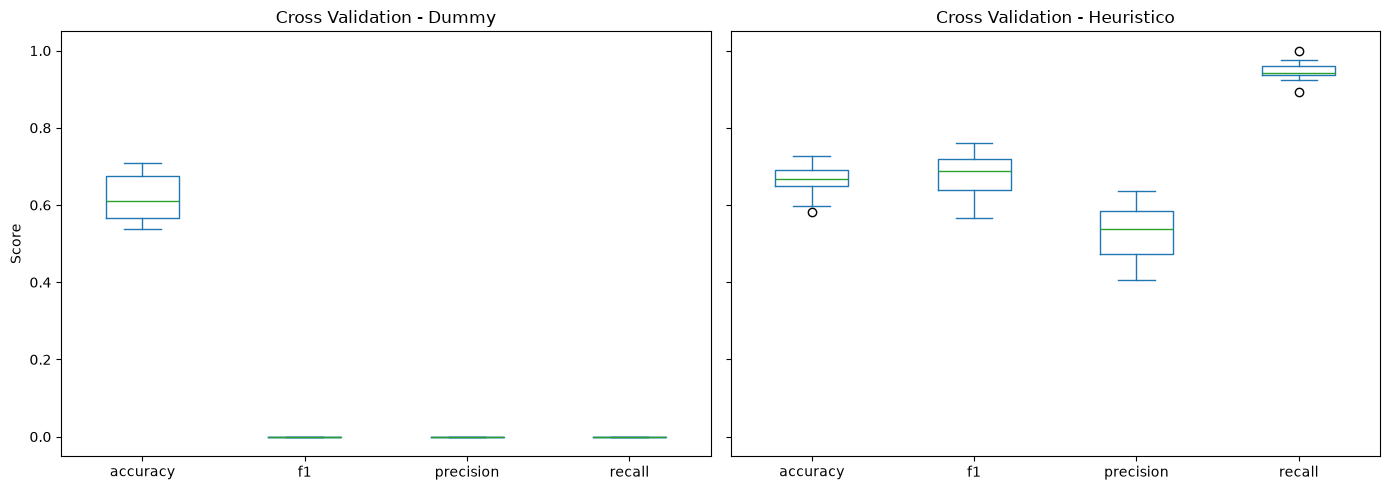

In [11]:
# Boxplot comparativo de las métricas de validación cruzada
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (nombre_modelo, metricas) in zip(axes, resultados_cv.items()):
    pd.DataFrame(metricas).plot.box(ax=ax, title=f"Cross Validation - {nombre_modelo}")
    ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

## 🎯 8. Evaluación final en test set (modelo heurístico)

In [ ]:
model_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", HeuristicModel())])
model_pipe.fit(x_train, y_train)

y_pred = model_pipe.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.54      0.69       182
           1       0.56      0.97      0.71       112

    accuracy                           0.70       294
   macro avg       0.77      0.76      0.70       294
weighted avg       0.82      0.70      0.70       294



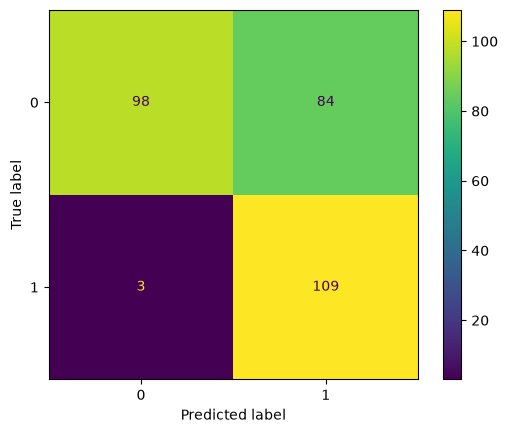

In [13]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

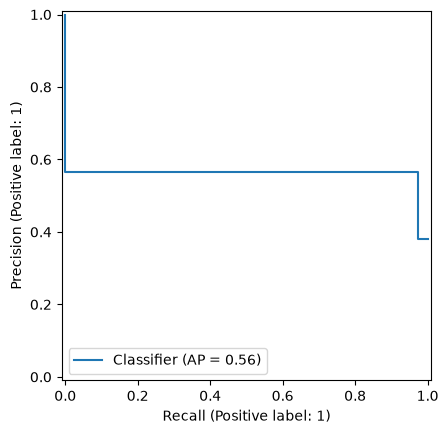

In [14]:
PrecisionRecallDisplay.from_predictions(y_test, y_pred);

### 8.1 ¿Por qué Recall como métrica principal?

En un problema de diagnóstico de enfermedad cardíaca, el error más costoso es un
**Falso Negativo** (decirle a un paciente enfermo que está sano) — puede significar no recibir
tratamiento a tiempo. Por eso, entre las métricas evaluadas, **Recall** (sensibilidad) es la más
relevante para este problema: mide qué proporción de los pacientes realmente enfermos el modelo
logra identificar correctamente.

## 📈 9. Learning Curve (basada en Recall)

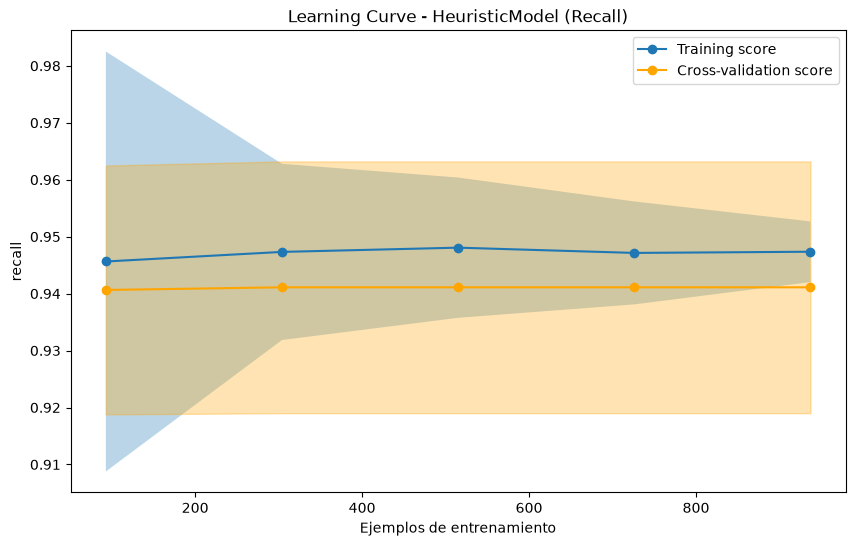

Training Sizes: [ 93 304 515 726 937]
Training Scores Mean: [0.94564039 0.94732524 0.94807005 0.94714572 0.94735453]
Training Scores Std: [0.03687391 0.01546919 0.01231455 0.00903808 0.00532768]
Test Scores Mean: [0.94064149 0.94110761 0.94110761 0.94110761 0.94110761]
Test Scores Std: [0.02185192 0.02210367 0.02210367 0.02210367 0.02210367]


In [ ]:
model = HeuristicModel()
model_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

common_params = {
    "X": x_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=123),
    "n_jobs": -1,
    "return_times": True,
}

scoring_metric = "recall"

train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    model_pipe, **common_params, scoring=scoring_metric
)

train_mean, train_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
test_mean, test_std = np.mean(test_scores, axis=1), np.std(test_scores, axis=1)
fit_times_mean, fit_times_std = np.mean(fit_times, axis=1), np.std(fit_times, axis=1)
score_times_mean, score_times_std = (
    np.mean(score_times, axis=1),
    np.std(score_times, axis=1),
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, "o-", label="Training score")
ax.plot(train_sizes, test_mean, "o-", color="orange", label="Cross-validation score")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.3)
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.3, color="orange")
ax.set_title(f"Learning Curve - {model.__class__.__name__} (Recall)")
ax.set_xlabel("Ejemplos de entrenamiento")
ax.set_ylabel(scoring_metric)
ax.legend(loc="best")
plt.show()

print("Training Sizes:", train_sizes)
print("Training Scores Mean:", train_mean)
print("Training Scores Std:", train_std)
print("Test Scores Mean:", test_mean)
print("Test Scores Std:", test_std)

## ⚙️ 10. Escalabilidad (tiempo de entrenamiento y score)

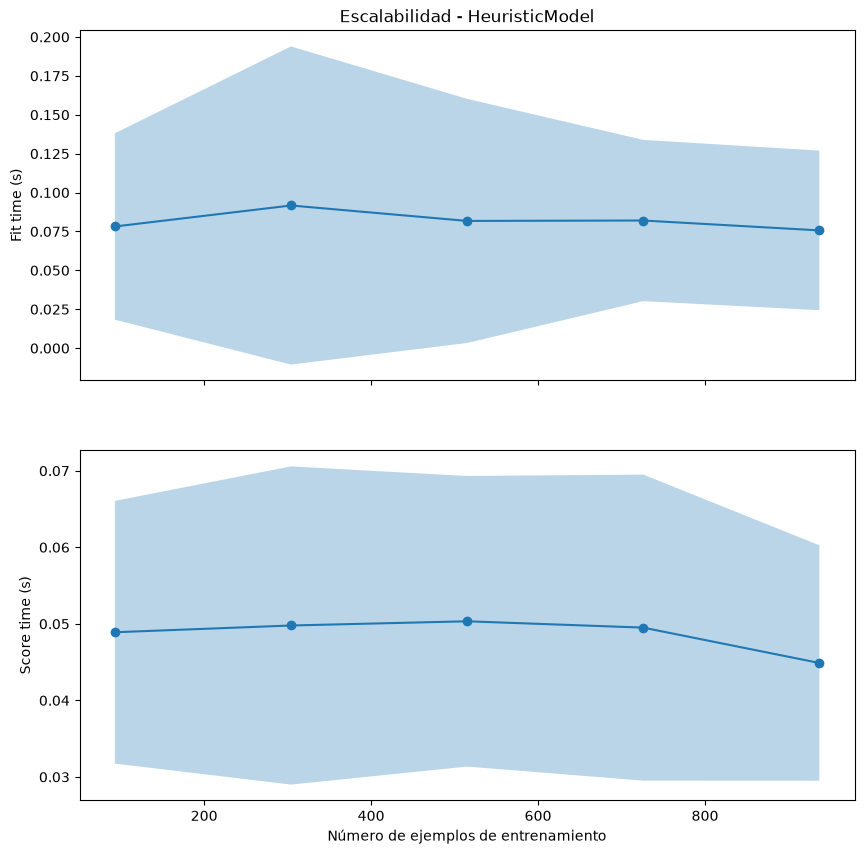

Fit Times Mean: [0.07820232 0.09168219 0.08177023 0.08203624 0.07568371]
Fit Times Std: [0.0598901  0.10223988 0.07845418 0.05181603 0.05129523]
Score Times Mean: [0.04890018 0.04978226 0.0503325  0.0495055  0.04488594]
Score Times Std: [0.01716228 0.02078621 0.01898382 0.01999392 0.01537965]


In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

ax[0].plot(train_sizes, fit_times_mean, "o-")
ax[0].fill_between(
    train_sizes,
    fit_times_mean - fit_times_std,
    fit_times_mean + fit_times_std,
    alpha=0.3,
)
ax[0].set_ylabel("Fit time (s)")
ax[0].set_title(f"Escalabilidad - {model.__class__.__name__}")

ax[1].plot(train_sizes, score_times_mean, "o-")
ax[1].fill_between(
    train_sizes,
    score_times_mean - score_times_std,
    score_times_mean + score_times_std,
    alpha=0.3,
)
ax[1].set_ylabel("Score time (s)")
ax[1].set_xlabel("Número de ejemplos de entrenamiento")

plt.show()

print("Fit Times Mean:", fit_times_mean)
print("Fit Times Std:", fit_times_std)
print("Score Times Mean:", score_times_mean)
print("Score Times Std:", score_times_std)

## 🔬 11. Interpretación de la Learning Curve

_Completar con base en las gráficas obtenidas:_

- **Brecha train/test**: si el score de entrenamiento es mucho mayor al de validación cruzada,
  hay señal de sobreajuste (poco esperable en un modelo heurístico simple, pero verificar).
- **Tendencia con más datos**: si el score de validación mejora al aumentar los datos de
  entrenamiento, sugiere que el modelo podría beneficiarse de más datos; si se estabiliza rápido
  (como es típico en un modelo de reglas fijas), significa que el modelo ya "convergió" y más
  datos no lo van a mejorar — hace falta un modelo con capacidad de aprendizaje real.
- **Escalabilidad**: el modelo heurístico debería tener tiempos de fit/score muy bajos y estables
  (no "aprende" parámetros), lo cual es esperado y no es una ventaja comparativa real frente a
  modelos de ML (que sí se benefician de más datos y cómputo).

## 📈 12. Análisis de resultados

_Completar con los valores numéricos reales obtenidos:_

### Resultados de validación cruzada
- **Accuracy**: media = _, std = _
- **F1**: media = _, std = _
- **Precision**: media = _, std = _
- **Recall**: media = _, std = _

### Comparación Dummy vs. Heurístico
- ¿El modelo heurístico supera al Dummy en Recall? (debería, si las reglas capturan señal real)
- ¿Qué tan grande es la diferencia? Esto define qué tan útil es el conocimiento de dominio
  incorporado en las reglas frente a no usar información alguna (Dummy).

## 📝 13. Conclusiones

- **Modelo base seleccionado:** modelo heurístico (basado en `chest_pain`, `thal`, `ca`)
- **Métrica principal:** Recall, por el costo alto de los Falsos Negativos en diagnóstico clínico
- **Desempeño general:** (completar con los números obtenidos)
- **Generalización:** (completar según la brecha train/test de la learning curve)
- **Utilidad como referencia:** este modelo baseline marca el piso mínimo de desempeño (Recall,
  Precision, F1) que cualquier modelo de ML entrenado en la siguiente etapa debe superar para
  justificar su mayor complejidad.

## 🧑‍🔬 14. Recomendaciones

1. **Usar este modelo como piso de comparación**: cualquier modelo de ML debe superar,
   como mínimo, el Recall obtenido por el modelo heurístico en el test set.
2. **No usar el modelo heurístico en producción**: sus reglas fijas no capturan interacciones
   complejas entre variables ni se ajustan a nuevos datos.
3. **Monitorear la métrica elegida (Recall)** de forma consistente en las siguientes etapas,
   para mantener comparabilidad entre modelos.

## 💡 15. Propuestas e ideas

1. **Modelos más complejos**: evaluar Regresión Logística, Random Forest, Gradient Boosting
   (ej. XGBoost) — pueden capturar interacciones no lineales entre variables clínicas.
2. **Usar todas las variables**: el modelo heurístico usa solo 3 columnas; los modelos de ML
   de la siguiente etapa deben aprovechar el pipeline completo de `4-feat_eng` (todas las
   variables, con escalado y encoding).
3. **Ajuste de hiperparámetros**: Grid Search / Random Search una vez seleccionado el modelo.
4. **Validación cruzada estratificada**: mantener `stratify` en el split y considerar
   `StratifiedKFold` en vez de `KFold` simple, dado el (leve) desbalance de clases del target.
5. **Costo de los errores**: considerar ajustar el umbral de decisión (no solo 0.5) en modelos
   probabilísticos, dado que el Falso Negativo es más costoso que el Falso Positivo en este
   problema clínico.